# 04 — So sánh kiến trúc mô hình: Phát hiện dấu hiệu thiếu máu cơ tim cấp (ACS)

**Dự án ACS-ECG-AI (Vinmec)** · **Bài toán 3** — phát hiện dấu hiệu thiếu máu cơ tim cấp (ACS)

Notebook này huấn luyện **4 kiến trúc 1D CNN khác nhau** trên **cùng một** pipeline tiền xử lý,
**cùng một** phép chia train/val theo bệnh nhân và **cùng một** seed — nên chênh lệch kết quả giữa
chúng phản ánh đúng kiến trúc chứ không phải may rủi của dữ liệu.

| mô hình | ý tưởng chính |
|---|---|
| **PlainCNN** | 4 khối Conv-BN-ReLU-MaxPool xếp chồng. Mốc sàn: nếu mô hình phức tạp không thắng được cái này thì độ phức tạp thêm vào là vô ích. |
| **ResNet1D** | Thêm skip connection để mạng sâu vẫn học được. Đây là mô hình dùng ở notebook `02_ischemia_acs_classifier.ipynb`. |
| **InceptionTime1D** | Mỗi khối nhìn tín hiệu bằng nhiều độ dài kernel song song (39/19/9), nên bắt được cả sóng nhanh (QRS) lẫn biến thiên chậm (đoạn ST). |
| **CNN+BiLSTM** | CNN rút đặc trưng cục bộ, rồi LSTM hai chiều mô hình hoá quan hệ theo thời gian giữa các nhịp. |

> Notebook tự chứa, chạy được trên **Google Colab** lẫn máy cá nhân.
> Bài toán còn lại được xử lý ở một notebook riêng — cố ý không gộp chung để mỗi bài toán có
> kết luận độc lập.

## 1. Cài thư viện

Chỉ cài `wfdb` nếu môi trường chưa có. Trên Colab cần cài lại mỗi phiên (~10 giây).

In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("wfdb") is None:
    print("Đang cài wfdb ...")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "wfdb"], check=True)

import wfdb

print("wfdb", wfdb.__version__)

wfdb 4.3.1


## 2. Cấu hình

Notebook chạy được trên **Google Colab** và **máy cá nhân**, tự nhận diện môi trường.
Chỉ cần sửa đúng một chỗ:

- **Colab** → `DRIVE_PROJECT` (tên thư mục trên Drive chứa `datasets.zip`)
- **Máy cá nhân** → `LOCAL_DATA_ROOT`

Ngoài ra đổi `RUN_MODE` khi muốn chuyển từ chạy thử sang chạy thật.

**Thư mục `outputs/` chỉ giữ hai thứ:** checkpoint mô hình và cache tín hiệu. Hình và bảng số
đều hiển thị ngay trong notebook nên không ghi ra file nữa.

Trên Colab, cache đặt ở `/content` (nhanh, mất khi hết phiên) và được sao lưu lên Drive để phiên
sau khỏi tiền xử lý lại; checkpoint ghi thẳng lên Drive để không mất khi đứt phiên.

In [2]:
import os
from pathlib import Path

import torch

# ===================== CHẾ ĐỘ CHẠY =====================
RUN_MODE = "full"        # "debug" = 200 bản ghi / 3 epoch  |  "full" = toàn bộ / 30 epoch

# ===================== ĐƯỜNG DẪN =======================
IS_COLAB = importlib.util.find_spec("google.colab") is not None

if IS_COLAB:
    DRIVE_PROJECT = Path("/content/drive/MyDrive/ACS-ECG-AI")   # <<< SỬA nếu đặt tên khác
    DRIVE_DATA_ZIP = DRIVE_PROJECT / "datasets.zip"             # <<< SỬA nếu tên zip khác
    DATA_ROOT = Path("/content/datasets")      # giải nén ra đĩa local cho nhanh
    WORK_DIR = Path("/content/work")           # tạm, mất khi hết phiên
    PERSIST_DIR = DRIVE_PROJECT / "outputs"    # bền qua các phiên
else:
    LOCAL_DATA_ROOT = r"C:\Users\anhquan\Workspace\AI_THUC_CHIEN\VSF_Projects\ECG-experiment\datasets"                    # <<< SỬA khi chạy máy cá nhân
    DATA_ROOT = Path(LOCAL_DATA_ROOT)
    WORK_DIR = DATA_ROOT.parent / "outputs"
    PERSIST_DIR = WORK_DIR

CACHE_DIR = WORK_DIR / "cache"                     # cache tín hiệu (sinh lại được)
MODEL_DIR = PERSIST_DIR / "models" / "acs_compare"  # checkpoint (không được mất)
DRIVE_CACHE_DIR = (PERSIST_DIR / "cache") if IS_COLAB else None

# ===================== THAM SỐ =========================
SEED = 42
FS, SIGNAL_LEN, NUM_LEADS = 500, 5000, 12      # 12 chuyển đạo × 10 giây @ 500 Hz
BP_LOW, BP_HIGH, BP_ORDER = 0.5, 40.0, 3       # bandpass Butterworth
VAL_SIZE = 0.15                                 # chia theo bệnh nhân 85/15
LR, WEIGHT_DECAY = 1e-3, 1e-4
EARLY_STOP_PATIENCE, LR_PATIENCE = 10, 5
ECE_BINS = 10
TARGET_LABEL = "label_ischemia"
CLASS_NAME = "ACS"

# Số bản ghi trong paper (tính trên toàn bộ 19.955); ta chỉ có nhãn cho 90% nên dung sai ±10%
PAPER_COUNTS = {"STEMI": 1513, "NSTEMI": 1274, "UA": 6197}
SANITY_TOL = 0.10

# ===================== SUY RA ==========================
GPU_AVAILABLE = torch.cuda.is_available()
DEVICE = torch.device("cuda" if GPU_AVAILABLE else "cpu")
DEBUG_LIMIT = 200
EPOCHS = 3 if RUN_MODE == "debug" else 30
BATCH_SIZE = 8 if RUN_MODE == "debug" else (64 if GPU_AVAILABLE else 16)
USE_AMP = GPU_AVAILABLE

print("Môi trường :", "Google Colab" if IS_COLAB else "máy cá nhân")
print("Thiết bị   :", DEVICE)
print("Chế độ     :", RUN_MODE, f"({EPOCHS} epoch, batch {BATCH_SIZE})")
print("Nhãn đích  :", TARGET_LABEL)

Môi trường : máy cá nhân
Thiết bị   : cuda
Chế độ     : full (30 epoch, batch 64)
Nhãn đích  : label_ischemia


### 2b. Chuẩn bị dữ liệu

Trên máy cá nhân cell này chỉ tạo thư mục. Trên Colab nó mount Drive (sẽ hiện popup xin quyền —
đây là thao tác thủ công duy nhất), copy `datasets.zip` về `/content` rồi giải nén.

Phải đi vòng qua zip vì bộ dữ liệu có **59.867 file**, mà Drive tính mỗi lần mở file là một lệnh
gọi mạng — đọc trực tiếp từ Drive sẽ chậm hơn hàng chục lần.

In [3]:
import shutil
import time
import zipfile


def _locate_data_root(search_root: Path) -> Path:
    """Tìm thư mục thật chứa dữ liệu, chịu được việc zip có bọc thêm lớp thư mục."""
    wanted = {"csv", "row_data", "raw_data", "med_data"}
    best, best_score = search_root, -1
    for cand in [search_root, *[p for p in search_root.rglob("*") if p.is_dir()]]:
        try:
            names = {c.name.lower() for c in cand.iterdir() if c.is_dir()}
        except OSError:
            continue
        if len(names & wanted) > best_score:
            best, best_score = cand, len(names & wanted)
        if best_score >= 2:
            break
    return best


def stage_colab_data() -> Path:
    marker = DATA_ROOT / ".staged_ok"
    if marker.exists():
        real = Path(marker.read_text().strip())
        print("Dữ liệu đã sẵn sàng:", real)
        return real

    if not DRIVE_DATA_ZIP.exists():
        có_gì = sorted(p.name for p in DRIVE_PROJECT.iterdir())[:40]
        raise FileNotFoundError(
            f"Không thấy {DRIVE_DATA_ZIP}\nTrong {DRIVE_PROJECT} hiện có: {có_gì}"
        )

    local_zip = Path("/content/_dataset.zip")
    size = DRIVE_DATA_ZIP.stat().st_size
    if not (local_zip.exists() and local_zip.stat().st_size == size):
        print(f"Copy zip {size / 1024 ** 3:.2f} GB từ Drive ...")
        t0 = time.time()
        shutil.copy2(DRIVE_DATA_ZIP, local_zip)
        print(f"  {time.time() - t0:.0f}s")

    extract_to = Path("/content/_extract")
    if extract_to.exists():
        shutil.rmtree(extract_to)
    print("Giải nén ...")
    t0 = time.time()
    with zipfile.ZipFile(local_zip) as zf:
        zf.extractall(extract_to)
    print(f"  {time.time() - t0:.0f}s")

    real = _locate_data_root(extract_to)
    real.mkdir(parents=True, exist_ok=True)
    (real / ".staged_ok").write_text(str(real))
    return real


if IS_COLAB:
    if str(DRIVE_PROJECT).startswith(("http://", "https://", "www.")):
        raise ValueError(
            "DRIVE_PROJECT đang là URL chia sẻ Drive. Phải là đường dẫn sau khi mount:\n"
            '    DRIVE_PROJECT = Path("/content/drive/MyDrive/ACS-ECG-AI")'
        )
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
    if not DRIVE_PROJECT.exists():
        my = Path("/content/drive/MyDrive")
        có_gì = sorted(p.name for p in my.iterdir() if p.is_dir())[:40] if my.exists() else []
        raise FileNotFoundError(
            f"Không thấy {DRIVE_PROJECT}\nCác thư mục trong MyDrive: {có_gì}"
        )

for d in [CACHE_DIR, MODEL_DIR] + ([DRIVE_CACHE_DIR] if DRIVE_CACHE_DIR else []):
    d.mkdir(parents=True, exist_ok=True)

if IS_COLAB:
    DATA_ROOT = stage_colab_data()

print("DATA_ROOT:", DATA_ROOT, "| tồn tại:", DATA_ROOT.exists())

DATA_ROOT: C:\Users\anhquan\Workspace\AI_THUC_CHIEN\VSF_Projects\ECG-experiment\datasets | tồn tại: True


## 3. Seed & GPU

In [4]:
import random

import numpy as np

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Input cố định (12 × 5000) nên cuDNN chọn thuật toán nhanh nhất một lần rồi giữ nguyên.
# Đánh đổi: epoch đầu chậm hơn vài giây, và kết quả không tái lập chính xác 100%.
torch.backends.cudnn.benchmark = GPU_AVAILABLE

print("torch", torch.__version__, "| GPU:", torch.cuda.get_device_name(0) if GPU_AVAILABLE else "không có")
if IS_COLAB and not GPU_AVAILABLE:
    print("\n" + "!" * 70)
    print("!! COLAB KHÔNG CÓ GPU -> Runtime > Change runtime type > GPU, rồi Run all lại.")
    print("!" * 70)

torch 2.11.0+cu128 | GPU: NVIDIA RTX 2000 Ada Generation Laptop GPU


## 4. Dữ liệu và nhãn

Nhãn chỉ có trong `train.csv` (phần 90% chính thức). `test.csv` là tập test ẩn, không có cột nhãn
và **không bao giờ được đọc** trong notebook này.

Sanity check đối chiếu số ca với paper. Dung sai ±10% chứ không phải ±2%, vì số của paper tính trên
toàn bộ 19.955 bản ghi còn ta chỉ đếm được trên 90% có nhãn.

In [5]:
import pandas as pd

pd.set_option("display.width", 200)


def find_dir(root: Path, names):
    wanted = {n.lower() for n in names}
    for c in sorted(root.iterdir()):
        if c.is_dir() and c.name.lower() in wanted:
            return c
    for c in root.rglob("*"):
        if c.is_dir() and c.name.lower() in wanted:
            return c
    return None


RAW_DIR = find_dir(DATA_ROOT, ["row_data", "raw_data"])
CSV_DIR = find_dir(DATA_ROOT, ["CSV", "csv"])
assert RAW_DIR and CSV_DIR, f"Không thấy row_data/ hoặc CSV/ trong {DATA_ROOT}"

df_raw = pd.read_csv(CSV_DIR / "train.csv")
df_raw["record_stem"] = df_raw["ecg_row_record"].astype(str).str.replace(".dat", "", regex=False)

COL_PATIENT, COL_AGE, COL_GENDER = "Patient_id", "age", "gender"
print(f"{len(df_raw):,} bản ghi | {df_raw[COL_PATIENT].nunique():,} bệnh nhân | "
      f"{len(list(RAW_DIR.glob('*.dat'))):,} file .dat")

# --- Sanity check ---
print(f"\n{'nhãn':<8}{'đếm được':>11}{'paper':>9}{'lệch':>9}")
ok_all = True
for name, expected in PAPER_COUNTS.items():
    got = int(df_raw[name].sum())
    delta = (got - expected) / expected
    ok_all &= abs(delta) <= SANITY_TOL
    print(f"{name:<8}{got:>11,}{expected:>9,}{delta:>8.1%}   {'OK' if abs(delta) <= SANITY_TOL else 'LỆCH'}")
if not ok_all:
    print("\n!! CẢNH BÁO: số ca lệch quá ±10% so với paper — kiểm tra lại nguồn dữ liệu.")

# --- Nhãn đích ---
df_all = df_raw.copy()
df_all[TARGET_LABEL] = ((df_all["STEMI"] == 1) | (df_all["NSTEMI"] == 1)
                        | (df_all["UA"] == 1)).astype(int)
print("Nhãn = STEMI | NSTEMI | UA  (proxy ACS theo định nghĩa của chính bộ dữ liệu)")
for c in ["STEMI", "NSTEMI", "UA"]:
    print(f"   {c:<7}: {int(df_all[c].sum()):>6,}")

n_pos = int(df_all[TARGET_LABEL].sum())
print(f"\nNhãn {TARGET_LABEL}: {n_pos:,} dương ({n_pos / len(df_all):.2%}) / "
      f"{len(df_all) - n_pos:,} âm")

17,960 bản ghi | 17,018 bệnh nhân | 19,955 file .dat

nhãn       đếm được    paper     lệch
STEMI         1,442    1,513   -4.7%   OK
NSTEMI        1,235    1,274   -3.1%   OK
UA            6,213    6,197    0.3%   OK
Nhãn = STEMI | NSTEMI | UA  (proxy ACS theo định nghĩa của chính bộ dữ liệu)
   STEMI  :  1,442
   NSTEMI :  1,235
   UA     :  6,213

Nhãn label_ischemia: 8,890 dương (49.50%) / 9,070 âm


## 5. Lấy mẫu khi chạy thử

Ở `RUN_MODE="debug"` lấy 200 bản ghi **stratified** theo nhãn, để tập mẫu không rơi vào toàn 0
hoặc toàn 1 (khi đó mọi metric sẽ vô định).

In [6]:
from sklearn.model_selection import train_test_split

if RUN_MODE == "debug" and len(df_all) > DEBUG_LIMIT:
    df, _ = train_test_split(df_all, train_size=DEBUG_LIMIT,
                             stratify=df_all[TARGET_LABEL], random_state=SEED)
    df = df.reset_index(drop=True)
else:
    df = df_all.reset_index(drop=True)

n_pos = int(df[TARGET_LABEL].sum())
print(f"Dùng {len(df):,} bản ghi | {n_pos:,} dương ({n_pos / len(df):.2%})")
assert 0 < n_pos < len(df), "Tập chỉ có một lớp — không train được."

Dùng 17,960 bản ghi | 8,890 dương (49.50%)


## 7. Tiền xử lý và cache

Với mỗi bản ghi: đọc WFDB → NaN→0 → cắt/đệm về đúng 5000 mẫu → bandpass Butterworth 0,5–40 Hz
(`filtfilt`, zero-phase). **Chuẩn hoá z-score làm sau**, ở bước 9, với mean/std tính riêng trên tập
train để không rò rỉ thống kê của val sang train.

Lọc lại toàn bộ ở mỗi epoch là nút thắt cổ chai, nên tín hiệu đã lọc được cache **một lần** vào
memmap `float16` (~2,2 GB cho 17.960 bản ghi). Cache nối tiếp được nếu bị ngắt giữa chừng, và trên
Colab được sao lưu lên Drive.

> **Hai bản ghi lỗi trong dữ liệu gốc.** `03228` và `14262` có file `.dat` chỉ chứa 3.500/5.000 mẫu,
> khiến `wfdb.rdrecord()` báo lỗi. Hàm dưới bắt lỗi đó, đọc phần thực có rồi để bước zero-pad bù nốt.

In [7]:
import hashlib
import json

from scipy.signal import butter, filtfilt

_B, _A = butter(BP_ORDER, [BP_LOW / (FS / 2), BP_HIGH / (FS / 2)], btype="band")
TRUNCATED = []


def load_signal(stem: str) -> np.ndarray:
    path = str(RAW_DIR / stem)
    try:
        rec = wfdb.rdrecord(path)
    except ValueError:                     # .dat ngắn hơn header khai báo
        n_sig = int((RAW_DIR / f"{stem}.hea").read_text().splitlines()[0].split()[1])
        n = (RAW_DIR / f"{stem}.dat").stat().st_size // (n_sig * 2)
        rec = wfdb.rdrecord(path, sampto=n)
        TRUNCATED.append(stem)
    return np.asarray(rec.p_signal, dtype=np.float32).T


def preprocess(sig: np.ndarray) -> np.ndarray:
    sig = np.nan_to_num(sig, nan=0.0, posinf=0.0, neginf=0.0)
    if sig.shape[1] < SIGNAL_LEN:
        sig = np.pad(sig, ((0, 0), (0, SIGNAL_LEN - sig.shape[1])))
    return np.ascontiguousarray(filtfilt(_B, _A, sig[:, :SIGNAL_LEN], axis=1), dtype=np.float32)


records = df["record_stem"].tolist()
_hash = hashlib.md5("|".join(records).encode()).hexdigest()[:8]
CACHE_NPY = CACHE_DIR / f"sig_{RUN_MODE}_n{len(df)}_{_hash}.npy"
CACHE_META = CACHE_DIR / f"sig_{RUN_MODE}_n{len(df)}_{_hash}.meta.json"


def _complete(meta_p: Path, npy_p: Path) -> bool:
    if not (meta_p.exists() and npy_p.exists()):
        return False
    try:
        return json.loads(meta_p.read_text()).get("n_done", 0) >= len(records)
    except (OSError, ValueError):
        return False


def build_cache() -> np.ndarray:
    # Colab: thử lấy lại cache của phiên trước từ Drive
    if DRIVE_CACHE_DIR and not _complete(CACHE_META, CACHE_NPY):
        d_npy, d_meta = DRIVE_CACHE_DIR / CACHE_NPY.name, DRIVE_CACHE_DIR / CACHE_META.name
        if _complete(d_meta, d_npy):
            print(f"Lấy cache từ Drive ({d_npy.stat().st_size / 1024 ** 3:.2f} GB) ...")
            t0 = time.time()
            shutil.copy2(d_npy, CACHE_NPY)
            shutil.copy2(d_meta, CACHE_META)
            print(f"  {time.time() - t0:.0f}s — bỏ qua tiền xử lý")

    if _complete(CACHE_META, CACHE_NPY):
        print("Cache đã đầy đủ:", CACHE_NPY.name)
        return np.load(CACHE_NPY, mmap_mode="r")

    meta = json.loads(CACHE_META.read_text()) if CACHE_META.exists() else {}
    start = int(meta.get("n_done", 0)) if CACHE_NPY.exists() else 0
    if start:
        arr = np.lib.format.open_memmap(CACHE_NPY, mode="r+")
        print(f"Build tiếp từ {start}/{len(records)}")
    else:
        print(f"Build cache {len(records):,} bản ghi "
              f"(~{len(records) * NUM_LEADS * SIGNAL_LEN * 2 / 1024 ** 3:.2f} GB)")
        arr = np.lib.format.open_memmap(CACHE_NPY, mode="w+", dtype=np.float16,
                                        shape=(len(records), NUM_LEADS, SIGNAL_LEN))

    t0 = time.time()
    step = max(1, len(records) // 8)
    for i in range(start, len(records)):
        arr[i] = preprocess(load_signal(records[i])).astype(np.float16)
        if (i + 1) % step == 0 or i + 1 == len(records):
            arr.flush()
            CACHE_META.write_text(json.dumps({"n_done": i + 1}))
            el = max(time.time() - t0, 1e-6)
            done = i + 1 - start
            print(f"  {i + 1:>6,}/{len(records):,}  {done / el:5.0f} rec/s  "
                  f"ETA {(len(records) - i - 1) / (done / el):4.0f}s")
    del arr
    print(f"Xong trong {time.time() - t0:.0f}s")

    if DRIVE_CACHE_DIR:
        print("Sao lưu cache lên Drive ...")
        shutil.copy2(CACHE_NPY, DRIVE_CACHE_DIR / CACHE_NPY.name)
        shutil.copy2(CACHE_META, DRIVE_CACHE_DIR / CACHE_META.name)
    return np.load(CACHE_NPY, mmap_mode="r")


CACHE = build_cache()
print("Cache:", CACHE.shape, CACHE.dtype)
if TRUNCATED:
    print(f"Bản ghi bị cắt ngắn, đã zero-pad: {TRUNCATED}")

Cache đã đầy đủ: sig_full_n17960_c20c6dba.npy
Cache: (17960, 12, 5000) float16


## 8. Xem thử tín hiệu

Kiểm tra bằng mắt trước khi train: tín hiệu có ra hình dạng ECG không, có bị phẳng hay bão hoà
không. Bổ sung từ notebook 01/02 — 03/04 vốn bỏ qua bước này khi được tạo lần đầu.

In [ ]:
LEADS = ["I", "II", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"]


def plot_12lead(sig, title, seconds=5.0):
    n = int(min(SIGNAL_LEN, seconds * FS))
    t = np.arange(n) / FS
    fig, axes = plt.subplots(6, 2, figsize=(13, 8), sharex=True)
    for k, ax in enumerate(axes.T.flatten()):
        ax.plot(t, sig[k, :n], lw=.7, color="#1f3b73")
        ax.set_ylabel(LEADS[k], rotation=0, ha="right", va="center", fontsize=9)
        ax.grid(alpha=.25)
        ax.tick_params(labelsize=7)
    axes[-1, 0].set_xlabel("giây")
    axes[-1, 1].set_xlabel("giây")
    fig.suptitle(title, fontsize=11)
    fig.tight_layout()
    plt.show()


for idx in list(df.index[df[TARGET_LABEL] == 1][:1]) + list(df.index[df[TARGET_LABEL] == 0][:1]):
    r = df.loc[idx]
    plot_12lead(np.asarray(CACHE[idx], dtype=np.float32),
                f"{r['record_stem']} | {TARGET_LABEL}={int(r[TARGET_LABEL])} | "
                f"tuổi {int(r[COL_AGE])} | đã lọc 0.5-40 Hz")

## 9. Chia train/val theo bệnh nhân

Bắt buộc chia theo `Patient_id`: một bệnh nhân có thể có nhiều ECG trong 7 ngày trước DSA, chia theo
bản ghi sẽ khiến cùng một người xuất hiện ở cả train lẫn val.

Stratify ở **cấp bệnh nhân** (lấy `max` nhãn của người đó) — cần thiết vì có bệnh nhân mang nhãn
không đồng nhất giữa các bản ghi của chính mình (xem mục 6).

Ngay sau khi chia, mean/std cho z-score được tính **chỉ trên các bản ghi thuộc train**.

In [8]:
pat = df.groupby(COL_PATIENT)[TARGET_LABEL].max().reset_index()
strat = pat[TARGET_LABEL] if pat[TARGET_LABEL].value_counts().min() >= 2 else None
pat_tr, pat_va = train_test_split(pat, test_size=VAL_SIZE, stratify=strat, random_state=SEED)

train_idx = df.index[df[COL_PATIENT].isin(set(pat_tr[COL_PATIENT]))].to_numpy()
val_idx = df.index[df[COL_PATIENT].isin(set(pat_va[COL_PATIENT]))].to_numpy()
y = df[TARGET_LABEL].values.astype(np.float32)

assert not (set(pat_tr[COL_PATIENT]) & set(pat_va[COL_PATIENT])), "RÒ RỈ: bệnh nhân ở cả 2 tập"
print("Giao nhau patient_id: RỖNG -> OK\n")

display(pd.DataFrame({
    "tập": ["train", "val"],
    "bệnh nhân": [len(pat_tr), len(pat_va)],
    "bản ghi": [len(train_idx), len(val_idx)],
    "dương": [int(y[train_idx].sum()), int(y[val_idx].sum())],
    "tỷ lệ dương": [f"{y[train_idx].mean():.2%}", f"{y[val_idx].mean():.2%}"],
}))


def norm_stats(idx, chunk=256):
    order = np.sort(np.asarray(idx))
    s = np.zeros(NUM_LEADS)
    ss = np.zeros(NUM_LEADS)
    cnt = 0
    for i in range(0, len(order), chunk):
        b = np.asarray(CACHE[order[i:i + chunk]], dtype=np.float64)
        s += b.sum(axis=(0, 2))
        ss += (b ** 2).sum(axis=(0, 2))
        cnt += b.shape[0] * b.shape[2]
    m = s / cnt
    return m.astype(np.float32), np.sqrt(np.maximum(ss / cnt - m ** 2, 1e-12)).astype(np.float32)


LEAD_MEAN, LEAD_STD = norm_stats(train_idx)
print(f"\nz-score fit trên {len(train_idx):,} bản ghi TRAIN")

Giao nhau patient_id: RỖNG -> OK



,tập,bệnh nhân,bản ghi,dương,tỷ lệ dương
0,train,14465,15266,7553,49.48%
1,val,2553,2694,1337,49.63%



z-score fit trên 15,266 bản ghi TRAIN


## 10. Dataset & DataLoader

In [9]:
from torch.utils.data import DataLoader, Dataset


class ECGDataset(Dataset):
    def __init__(self, indices, labels):
        self.indices = np.asarray(indices)
        self.labels = np.asarray(labels, dtype=np.float32)
        self.mean = LEAD_MEAN.reshape(-1, 1)
        self.std = LEAD_STD.reshape(-1, 1)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        x = np.asarray(CACHE[self.indices[i]], dtype=np.float32)
        return torch.from_numpy((x - self.mean) / self.std), torch.tensor(self.labels[i])


# Windows tạo worker bằng spawn (mỗi worker nạp lại cả notebook) nên để 0; Linux dùng fork -> 2
NUM_WORKERS = 0 if os.name == "nt" else 2
_extra = dict(persistent_workers=True, prefetch_factor=4) if NUM_WORKERS else {}

train_loader = DataLoader(ECGDataset(train_idx, y[train_idx]), batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=GPU_AVAILABLE, **_extra)
val_loader = DataLoader(ECGDataset(val_idx, y[val_idx]), batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=GPU_AVAILABLE, **_extra)

xb, yb = next(iter(train_loader))
print(f"batch: {tuple(xb.shape)} {xb.dtype} | nhãn {tuple(yb.shape)} | "
      f"{len(train_loader)} batch train, {len(val_loader)} batch val")

batch: (64, 12, 5000) torch.float32 | nhãn (64,) | 239 batch train, 43 batch val


## 11. Hàm tính metric

`compute_metrics` an toàn với tập nhỏ: khi chỉ có một lớp hoặc mẫu số bằng 0, trả `nan` thay vì
ném lỗi hay trả 0 gây hiểu nhầm.

`per_class_report` cho bảng tách riêng **lớp âm tính (0)** và **lớp dương tính (1)** — mỗi lớp có
Precision/Recall/F1/Support riêng, kèm hai dòng trung bình macro và weighted.

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import (average_precision_score, brier_score_loss, confusion_matrix,
                             precision_recall_fscore_support, roc_auc_score)

plt.rcParams["figure.dpi"] = 110


def _div(a, b):
    return float(a) / float(b) if b else float("nan")


def compute_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int).ravel()
    y_prob = np.asarray(y_prob, dtype=np.float64).ravel()
    y_pred = (y_prob >= threshold).astype(int)
    two = len(np.unique(y_true)) == 2
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "auroc": roc_auc_score(y_true, y_prob) if two else float("nan"),
        "auprc": average_precision_score(y_true, y_prob) if two else float("nan"),
        "sensitivity": _div(tp, tp + fn), "specificity": _div(tn, tn + fp),
        "ppv": _div(tp, tp + fp), "npv": _div(tn, tn + fn),
        "f1": _div(2 * tp, 2 * tp + fp + fn),
        "accuracy": _div(tp + tn, tp + tn + fp + fn),
        "brier": float(brier_score_loss(y_true, y_prob)) if two else float("nan"),
        "threshold": float(threshold),
        "tp": int(tp), "fp": int(fp), "tn": int(tn), "fn": int(fn),
        "n": int(len(y_true)), "n_pos": int(y_true.sum()),
    }


def per_class_report(y_true, y_prob, threshold):
    """Bảng metric TÁCH RIÊNG cho lớp 0 và lớp 1, kiểu classification_report của sklearn."""
    y_true = np.asarray(y_true).astype(int).ravel()
    y_pred = (np.asarray(y_prob).ravel() >= threshold).astype(int)
    p, r, f, s = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1], zero_division=0)
    rows = [
        {"Class": f"Negative (0) — không {CLASS_NAME}", "Precision": p[0], "Recall": r[0],
         "F1": f[0], "Support": int(s[0])},
        {"Class": f"Positive (1) — {CLASS_NAME}", "Precision": p[1], "Recall": r[1],
         "F1": f[1], "Support": int(s[1])},
    ]
    w = s / s.sum()
    rows.append({"Class": "macro avg", "Precision": p.mean(), "Recall": r.mean(),
                 "F1": f.mean(), "Support": int(s.sum())})
    rows.append({"Class": "weighted avg", "Precision": float(p @ w), "Recall": float(r @ w),
                 "F1": float(f @ w), "Support": int(s.sum())})
    return pd.DataFrame(rows).set_index("Class")


def style_df(df, pct_cols):
    fmt = {c: "{:.4f}" for c in pct_cols}
    fmt.update({c: "{:,d}" for c in df.columns if c not in pct_cols and df[c].dtype.kind in "iu"})
    try:
        return df.style.format(fmt, na_rep="n/a").background_gradient(
            cmap="Blues", vmin=0, vmax=1, subset=[c for c in pct_cols if c in df.columns])
    except Exception:
        return df.round(4)


print("self-test:", {k: round(v, 3) for k, v in
                     compute_metrics([0, 0, 1, 1], [.1, .4, .35, .8]).items()
                     if k in ("auroc", "f1", "sensitivity")})

self-test: {'auroc': np.float64(0.75), 'sensitivity': 0.5, 'f1': 0.667}


## 12. Bốn kiến trúc

Tất cả nhận input `(batch, 12, 5000)` và trả về **một logit** cho mỗi mẫu, nên có thể thay thế nhau
trong đúng một vòng lặp huấn luyện.

Cả bốn đều hạ chiều thời gian khá mạnh (5000 → vài chục) trước khi gộp, vì tín hiệu 10 giây ở 500 Hz
là quá dài để giữ nguyên độ phân giải qua nhiều tầng.

In [11]:
import torch.nn as nn


# ---------------------------------------------------------------- 1. PlainCNN
class PlainCNN(nn.Module):
    """Mốc sàn: Conv-BN-ReLU-MaxPool xếp chồng, không có gì đặc biệt."""

    def __init__(self, channels=(32, 64, 128, 256)):
        super().__init__()
        layers, c_in = [], NUM_LEADS
        for c_out in channels:
            layers += [nn.Conv1d(c_in, c_out, 7, padding=3, bias=False),
                       nn.BatchNorm1d(c_out), nn.ReLU(inplace=True), nn.MaxPool1d(4)]
            c_in = c_out
        self.features = nn.Sequential(*layers)
        self.head = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                  nn.Dropout(0.3), nn.Linear(c_in, 1))

    def forward(self, x):
        return self.head(self.features(x)).squeeze(-1)


# ---------------------------------------------------------------- 2. ResNet1D
class ResidualBlock1D(nn.Module):
    def __init__(self, c_in, c_out, k=7, stride=2, dropout=0.1):
        super().__init__()
        self.conv1 = nn.Conv1d(c_in, c_out, k, stride, k // 2, bias=False)
        self.bn1 = nn.BatchNorm1d(c_out)
        self.conv2 = nn.Conv1d(c_out, c_out, k, 1, k // 2, bias=False)
        self.bn2 = nn.BatchNorm1d(c_out)
        self.drop = nn.Dropout(dropout)
        self.relu = nn.ReLU(inplace=True)
        self.short = (nn.Identity() if (stride == 1 and c_in == c_out)
                      else nn.Sequential(nn.Conv1d(c_in, c_out, 1, stride, bias=False),
                                         nn.BatchNorm1d(c_out)))

    def forward(self, x):
        idt = self.short(x)
        out = self.drop(self.relu(self.bn1(self.conv1(x))))
        return self.relu(self.bn2(self.conv2(out)) + idt)


class ResNet1D(nn.Module):
    """Skip connection giúp gradient đi xuyên qua mạng sâu."""

    def __init__(self, channels=(32, 64, 128, 256), dropout=0.3):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv1d(NUM_LEADS, 32, 15, 2, 7, bias=False),
                                  nn.BatchNorm1d(32), nn.ReLU(inplace=True), nn.MaxPool1d(2))
        blocks, c_in = [], 32
        for c_out in channels:
            blocks.append(ResidualBlock1D(c_in, c_out, stride=2))
            c_in = c_out
        self.blocks = nn.Sequential(*blocks)
        self.head = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                  nn.Linear(c_in, 64), nn.ReLU(inplace=True),
                                  nn.Dropout(dropout), nn.Linear(64, 1))

    def forward(self, x):
        return self.head(self.blocks(self.stem(x))).squeeze(-1)


# ---------------------------------------------------------------- 3. InceptionTime1D
class InceptionModule(nn.Module):
    """Nhiều độ dài kernel song song -> bắt được cả sóng nhanh lẫn biến thiên chậm."""

    def __init__(self, c_in, n_filters=32, kernels=(39, 19, 9), bottleneck=32):
        super().__init__()
        self.bottleneck = nn.Conv1d(c_in, bottleneck, 1, bias=False)
        self.convs = nn.ModuleList(
            [nn.Conv1d(bottleneck, n_filters, k, padding=k // 2, bias=False) for k in kernels])
        self.pool_conv = nn.Sequential(nn.MaxPool1d(3, stride=1, padding=1),
                                       nn.Conv1d(c_in, n_filters, 1, bias=False))
        self.bn = nn.BatchNorm1d(n_filters * (len(kernels) + 1))
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        b = self.bottleneck(x)
        return self.relu(self.bn(torch.cat([c(b) for c in self.convs] + [self.pool_conv(x)], 1)))


class InceptionTime1D(nn.Module):
    def __init__(self, n_filters=32, depth=6):
        super().__init__()
        # hạ tần số ngay từ đầu, nếu không 5000 mẫu × nhiều kênh sẽ quá nặng
        self.stem = nn.Sequential(nn.Conv1d(NUM_LEADS, 32, 15, 4, 7, bias=False),
                                  nn.BatchNorm1d(32), nn.ReLU(inplace=True))
        c_out = n_filters * 4
        self.blocks = nn.ModuleList()
        self.shortcuts = nn.ModuleList()
        self.pools = nn.ModuleList()
        c_in = 32
        res_c = 32          # số kênh của tensor dùng làm residual, KHÁC c_in của khối hiện tại
        for d in range(depth):
            self.blocks.append(InceptionModule(c_in, n_filters))
            # residual mỗi 3 khối, kèm hạ chiều thời gian
            if d % 3 == 2:
                self.shortcuts.append(nn.Sequential(nn.Conv1d(res_c, c_out, 1, bias=False),
                                                    nn.BatchNorm1d(c_out)))
                self.pools.append(nn.MaxPool1d(4))
                res_c = c_out
            else:
                self.shortcuts.append(None)
                self.pools.append(None)
            c_in = c_out
        self.relu = nn.ReLU(inplace=True)
        self.head = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                  nn.Dropout(0.3), nn.Linear(c_out, 1))

    def forward(self, x):
        x = self.stem(x)
        res = x
        for blk, short, pool in zip(self.blocks, self.shortcuts, self.pools):
            x = blk(x)
            if short is not None:
                x = self.relu(x + short(res))
                x = pool(x)
                res = x
        return self.head(x).squeeze(-1)


# ---------------------------------------------------------------- 4. CNN + BiLSTM
class CNNBiLSTM(nn.Module):
    """CNN rút đặc trưng cục bộ, BiLSTM mô hình hoá quan hệ theo thời gian giữa các nhịp."""

    def __init__(self, hidden=128):
        super().__init__()
        layers, c_in = [], NUM_LEADS
        for c_out in (32, 64, 128):
            layers += [nn.Conv1d(c_in, c_out, 7, padding=3, bias=False),
                       nn.BatchNorm1d(c_out), nn.ReLU(inplace=True), nn.MaxPool1d(4)]
            c_in = c_out
        self.cnn = nn.Sequential(*layers)                       # 5000 -> ~78
        self.lstm = nn.LSTM(c_in, hidden, batch_first=True, bidirectional=True)
        self.head = nn.Sequential(nn.Dropout(0.3), nn.Linear(hidden * 2, 1))

    def forward(self, x):
        h = self.cnn(x).transpose(1, 2)                          # (B, T, C)
        out, _ = self.lstm(h)
        return self.head(out.mean(dim=1)).squeeze(-1)            # gộp trung bình theo thời gian


MODELS = {
    "PlainCNN": PlainCNN,
    "ResNet1D": ResNet1D,
    "InceptionTime1D": InceptionTime1D,
    "CNN+BiLSTM": CNNBiLSTM,
}

rows = []
for name, cls in MODELS.items():
    m = cls().to(DEVICE)
    with torch.no_grad():
        out = m(torch.zeros(2, NUM_LEADS, SIGNAL_LEN, device=DEVICE))
    rows.append({"Mô hình": name, "Tham số": sum(p.numel() for p in m.parameters()),
                 "Output": str(tuple(out.shape))})
    del m
torch.cuda.empty_cache() if GPU_AVAILABLE else None
display(pd.DataFrame(rows).set_index("Mô hình"))

,Tham số,Output
Mô hình,,
PlainCNN,304961,"(2,)"
ResNet1D,986753,"(2,)"
InceptionTime1D,483137,"(2,)"
CNN+BiLSTM,339265,"(2,)"


## 13. Huấn luyện lần lượt bốn mô hình

Mỗi mô hình được train bằng đúng một hàm, đúng một cấu hình: `BCEWithLogitsLoss` với `pos_weight`
tính từ tỷ lệ lớp trong train, AdamW, `ReduceLROnPlateau` theo val AUPRC, early stopping patience 10.
Seed được đặt lại trước mỗi mô hình để việc khởi tạo trọng số không phụ thuộc thứ tự chạy.

**Chạy lại được sau khi mất phiên:** mô hình nào đã có checkpoint khớp cấu hình thì được nạp lại và
bỏ qua bước train, nên Run all lần hai chỉ train tiếp những mô hình còn thiếu.

In [12]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

n_pos_tr = int(y[train_idx].sum())
POS_WEIGHT = float((len(train_idx) - n_pos_tr) / max(n_pos_tr, 1))
FINGERPRINT = dict(run_mode=RUN_MODE, target=TARGET_LABEL, n_train=len(train_idx), epochs=EPOCHS)
print(f"pos_weight = {POS_WEIGHT:.2f} | {EPOCHS} epoch tối đa mỗi mô hình\n")


def evaluate(model, loader):
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE, non_blocking=True)
            with torch.amp.autocast("cuda", enabled=USE_AMP):
                logits = model(xb)
            ys.append(yb.numpy())
            ps.append(torch.sigmoid(logits.float()).cpu().numpy())
    return np.concatenate(ys), np.concatenate(ps)


def train_one(name, cls):
    ckpt_path = MODEL_DIR / f"{name.replace('+', '_')}_best.pt"

    if ckpt_path.exists():
        ck = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
        if ck.get("fp") == FINGERPRINT:
            model = cls().to(DEVICE)
            model.load_state_dict(ck["model"])
            print(f"[{name}] đã có checkpoint khớp -> bỏ qua train "
                  f"(best AUPRC {ck['best']:.4f} @ ep {ck['best_epoch']})")
            return model, ck["hist"], ck["best_epoch"], ck["seconds"]

    torch.manual_seed(SEED)
    np.random.seed(SEED)
    model = cls().to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([POS_WEIGHT], device=DEVICE))
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=.5, patience=LR_PATIENCE)
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

    best, best_epoch, bad, hist = -np.inf, -1, 0, []
    t_all = time.time()
    for epoch in range(EPOCHS):
        t0 = time.time()
        model.train()
        tot, seen = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=USE_AMP):
                loss = criterion(model(xb), yb)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            tot += loss.item() * xb.size(0)
            seen += xb.size(0)

        va_y, va_p = evaluate(model, val_loader)
        m = compute_metrics(va_y, va_p)
        scheduler.step(m["auprc"] if not np.isnan(m["auprc"]) else -np.inf)
        hist.append({"epoch": epoch + 1, "train_loss": tot / max(seen, 1),
                     "val_auprc": m["auprc"], "val_auroc": m["auroc"]})

        if (not np.isnan(m["auprc"])) and m["auprc"] > best:
            best, best_epoch, bad = float(m["auprc"]), epoch + 1, 0
            torch.save({"model": model.state_dict(), "fp": FINGERPRINT, "best": best,
                        "best_epoch": best_epoch, "hist": hist,
                        "seconds": round(time.time() - t_all, 1)}, ckpt_path)
        else:
            bad += 1

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  [{name}] ep {epoch + 1:>3}/{EPOCHS}  {time.time() - t0:5.1f}s  "
                  f"loss {tot / max(seen, 1):.4f}  val auprc {m['auprc']:.4f}  auroc {m['auroc']:.4f}")
        if bad >= EARLY_STOP_PATIENCE:
            print(f"  [{name}] early stop @ epoch {epoch + 1}")
            break

    seconds = round(time.time() - t_all, 1)
    ck = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    ck["seconds"] = seconds
    ck["hist"] = hist
    torch.save(ck, ckpt_path)
    model.load_state_dict(ck["model"])
    print(f"[{name}] xong {len(hist)} epoch trong {seconds:.0f}s | "
          f"best AUPRC {best:.4f} @ ep {best_epoch}")
    return model, hist, best_epoch, seconds


RESULTS = {}
for name, cls in MODELS.items():
    print(f"\n=== {name} " + "=" * (60 - len(name)))
    model, hist, best_epoch, seconds = train_one(name, cls)
    va_y, va_p = evaluate(model, val_loader)
    RESULTS[name] = {"y": va_y, "p": va_p, "hist": hist,
                     "best_epoch": best_epoch, "seconds": seconds,
                     "params": sum(q.numel() for q in model.parameters())}
    del model
    if GPU_AVAILABLE:
        torch.cuda.empty_cache()

print("\nĐã train xong", len(RESULTS), "mô hình.")

pos_weight = 1.02 | 30 epoch tối đa mỗi mô hình


=== PlainCNN ====================================================


  [PlainCNN] ep   1/30   11.7s  loss 0.6891  val auprc 0.6248  auroc 0.6273


  [PlainCNN] ep   5/30    6.5s  loss 0.6501  val auprc 0.6634  auroc 0.6697


  [PlainCNN] ep  10/30    9.5s  loss 0.6343  val auprc 0.6708  auroc 0.6746


  [PlainCNN] ep  15/30    7.2s  loss 0.6219  val auprc 0.6838  auroc 0.6858


...

  [CNN+BiLSTM] ep  15/30    7.2s  loss 0.6188  val auprc 0.6808  auroc 0.6769


  [CNN+BiLSTM] ep  20/30    7.5s  loss 0.6000  val auprc 0.6825  auroc 0.6823


  [CNN+BiLSTM] ep  25/30    5.0s  loss 0.5801  val auprc 0.6580  auroc 0.6539


  [CNN+BiLSTM] ep  30/30    7.4s  loss 0.5357  val auprc 0.6808  auroc 0.6757
[CNN+BiLSTM] xong 30 epoch trong 187s | best AUPRC 0.6909 @ ep 22



Đã train xong 4 mô hình.


## 14. Bảng so sánh bốn mô hình

Mỗi mô hình chọn ngưỡng riêng theo **Youden's J** trên tập validation của chính nó, nên cột
`Threshold` khác nhau giữa các dòng là bình thường.

Cách đọc: **`AUROC` và `AUPRC` là hai cột duy nhất không phụ thuộc ngưỡng**, nên dùng chúng để xếp
hạng mô hình. `Prevalence` là mức AUPRC mà một mô hình đoán ngẫu nhiên đạt được — luôn so `AUPRC`
với con số này chứ đừng đọc nó một mình.

In [13]:
COLS = ["AUROC", "AUPRC", "F1", "Precision", "Sensitivity_Recall", "Specificity",
        "Accuracy", "Threshold", "Prevalence", "TP", "TN", "FP", "FN", "NPV"]
PCT = ["AUROC", "AUPRC", "F1", "Precision", "Sensitivity_Recall", "Specificity",
       "Accuracy", "Threshold", "Prevalence", "NPV"]

from sklearn.metrics import precision_recall_curve, roc_curve

for name, r in RESULTS.items():
    if len(np.unique(r["y"].astype(int))) == 2:
        fpr, tpr, thr = roc_curve(r["y"], r["p"])
        r["threshold"] = float(np.clip(thr[int(np.argmax(tpr - fpr))], 0, 1))
    else:
        r["threshold"] = 0.5
    r["metrics"] = compute_metrics(r["y"], r["p"], r["threshold"])

rows = []
for name, r in RESULTS.items():
    m = r["metrics"]
    rows.append({"Model": name, "AUROC": m["auroc"], "AUPRC": m["auprc"], "F1": m["f1"],
                 "Precision": m["ppv"], "Sensitivity_Recall": m["sensitivity"],
                 "Specificity": m["specificity"], "Accuracy": m["accuracy"],
                 "Threshold": m["threshold"], "Prevalence": m["n_pos"] / m["n"],
                 "TP": m["tp"], "TN": m["tn"], "FP": m["fp"], "FN": m["fn"], "NPV": m["npv"]})

compare_df = pd.DataFrame(rows).set_index("Model")[COLS].sort_values("AUPRC", ascending=False)
print("=" * 78)
print(f"SO SÁNH MÔ HÌNH — {CLASS_NAME} | tập validation {len(val_idx):,} bản ghi")
print("=" * 78)
display(style_df(compare_df, PCT))

cost_df = pd.DataFrame([
    {"Model": n, "Tham số": r["params"], "Thời gian train (s)": r["seconds"],
     "Số epoch": len(r["hist"]), "Best epoch": r["best_epoch"]}
    for n, r in RESULTS.items()]).set_index("Model")
print("\nChi phí huấn luyện:")
display(cost_df)

BEST_MODEL = compare_df.index[0]
print(f"\n-> Mô hình tốt nhất theo AUPRC: {BEST_MODEL} "
      f"(AUROC {compare_df.loc[BEST_MODEL, 'AUROC']:.4f}, "
      f"AUPRC {compare_df.loc[BEST_MODEL, 'AUPRC']:.4f})")

print("\nBài toán ACS không có ngưỡng pass/fail bắt buộc. Lưu ý khi diễn giải: nhãn này gộp cả UA,")
print("mà đau thắt ngực không ổn định theo định nghĩa thường KHÔNG có thay đổi đặc trưng trên ECG —")
print("nên trần hiệu năng của mọi kiến trúc ở đây đều thấp hơn hẳn bài STEMI.")


SO SÁNH MÔ HÌNH — ACS | tập validation 2,694 bản ghi


,AUROC,AUPRC,F1,Precision,Sensitivity_Recall,Specificity,Accuracy,Threshold,Prevalence,TP,TN,FP,FN,NPV
Model,,,,,,,,,,,,,,
PlainCNN,0.6970,0.6975,0.6301,0.6462,0.6148,0.6684,0.6418,0.4516,0.4963,822,907,450,515,0.6378
CNN+BiLSTM,0.6860,0.6909,0.5899,0.6578,0.5348,0.7259,0.6310,0.5376,0.4963,715,985,372,622,0.6129
InceptionTime1D,0.6847,0.6885,0.6058,0.6426,0.5729,0.6861,0.6299,0.4719,0.4963,766,931,426,571,0.6198
ResNet1D,0.6819,0.6815,0.5851,0.6715,0.5183,0.7502,0.6351,0.5032,0.4963,693,"1,018",339,644,0.6125



Chi phí huấn luyện:


,Tham số,Thời gian train (s),Số epoch,Best epoch
Model,,,,
PlainCNN,304961,221.6,30,28
ResNet1D,986753,244.4,30,23
InceptionTime1D,483137,331.9,25,15
CNN+BiLSTM,339265,186.9,30,22



-> Mô hình tốt nhất theo AUPRC: PlainCNN (AUROC 0.6970, AUPRC 0.6975)

Bài toán ACS không có ngưỡng pass/fail bắt buộc. Lưu ý khi diễn giải: nhãn này gộp cả UA,
mà đau thắt ngực không ổn định theo định nghĩa thường KHÔNG có thay đổi đặc trưng trên ECG —
nên trần hiệu năng của mọi kiến trúc ở đây đều thấp hơn hẳn bài STEMI.


## 14b. Bảng tóm tắt gọn

Rút gọn từ bảng so sánh ở trên, chỉ giữ các metric chính — tiện để chụp màn hình hoặc dán vào báo cáo.

In [ ]:
summary_df = compare_df[["AUROC", "AUPRC", "F1", "Precision", "Sensitivity_Recall",
                         "Specificity", "Accuracy"]].rename(columns={"Sensitivity_Recall": "Sensitivity"})
summary_df.index.name = "Mô hình"
display(style_df(summary_df, summary_df.columns.tolist()))

## 15. Metric tách riêng từng lớp

Với mỗi mô hình, bảng dưới tách **lớp âm tính (0)** và **lớp dương tính (1)** thành hai dòng riêng,
mỗi dòng có Precision/Recall/F1/Support của chính lớp đó.

Đây mới là chỗ nhìn ra mô hình thực sự làm được gì: một mô hình có `Accuracy` cao vẫn có thể gần như
vô dụng ở dòng `Positive (1)` nếu nó chỉ đang đoán "âm tính" cho gần hết mọi ca.

In [14]:
for name in compare_df.index:
    r = RESULTS[name]
    m = r["metrics"]
    print("\n" + "=" * 78)
    print(f"{name}   |   AUROC {m['auroc']:.4f}   AUPRC {m['auprc']:.4f}   "
          f"ngưỡng {r['threshold']:.4f}")
    print("=" * 78)
    display(style_df(per_class_report(r["y"], r["p"], r["threshold"]),
                     ["Precision", "Recall", "F1"]))


PlainCNN   |   AUROC 0.6970   AUPRC 0.6975   ngưỡng 0.4516


,Precision,Recall,F1,Support
Class,,,,
Negative (0) — không ACS,0.6378,0.6684,0.6528,"1,357"
Positive (1) — ACS,0.6462,0.6148,0.6301,"1,337"
macro avg,0.6420,0.6416,0.6414,"2,694"
weighted avg,0.6420,0.6418,0.6415,"2,694"



CNN+BiLSTM   |   AUROC 0.6860   AUPRC 0.6909   ngưỡng 0.5376


,Precision,Recall,F1,Support
Class,,,,
Negative (0) — không ACS,0.6129,0.7259,0.6646,"1,357"
Positive (1) — ACS,0.6578,0.5348,0.5899,"1,337"
macro avg,0.6354,0.6303,0.6273,"2,694"
weighted avg,0.6352,0.6310,0.6276,"2,694"



InceptionTime1D   |   AUROC 0.6847   AUPRC 0.6885   ngưỡng 0.4719


,Precision,Recall,F1,Support
Class,,,,
Negative (0) — không ACS,0.6198,0.6861,0.6513,"1,357"
Positive (1) — ACS,0.6426,0.5729,0.6058,"1,337"
macro avg,0.6312,0.6295,0.6285,"2,694"
weighted avg,0.6311,0.6299,0.6287,"2,694"



ResNet1D   |   AUROC 0.6819   AUPRC 0.6815   ngưỡng 0.5032


,Precision,Recall,F1,Support
Class,,,,
Negative (0) — không ACS,0.6125,0.7502,0.6744,"1,357"
Positive (1) — ACS,0.6715,0.5183,0.5851,"1,337"
macro avg,0.6420,0.6343,0.6297,"2,694"
weighted avg,0.6418,0.6351,0.6301,"2,694"


## 16. Đường cong học và ROC / PR chồng lên nhau

Ba biểu đồ này trả lời ba câu khác nhau: mô hình nào học nhanh và ổn định hơn, mô hình nào phân biệt
tốt hơn trên toàn dải ngưỡng, và mô hình nào giữ được Precision khi đẩy Recall lên cao.

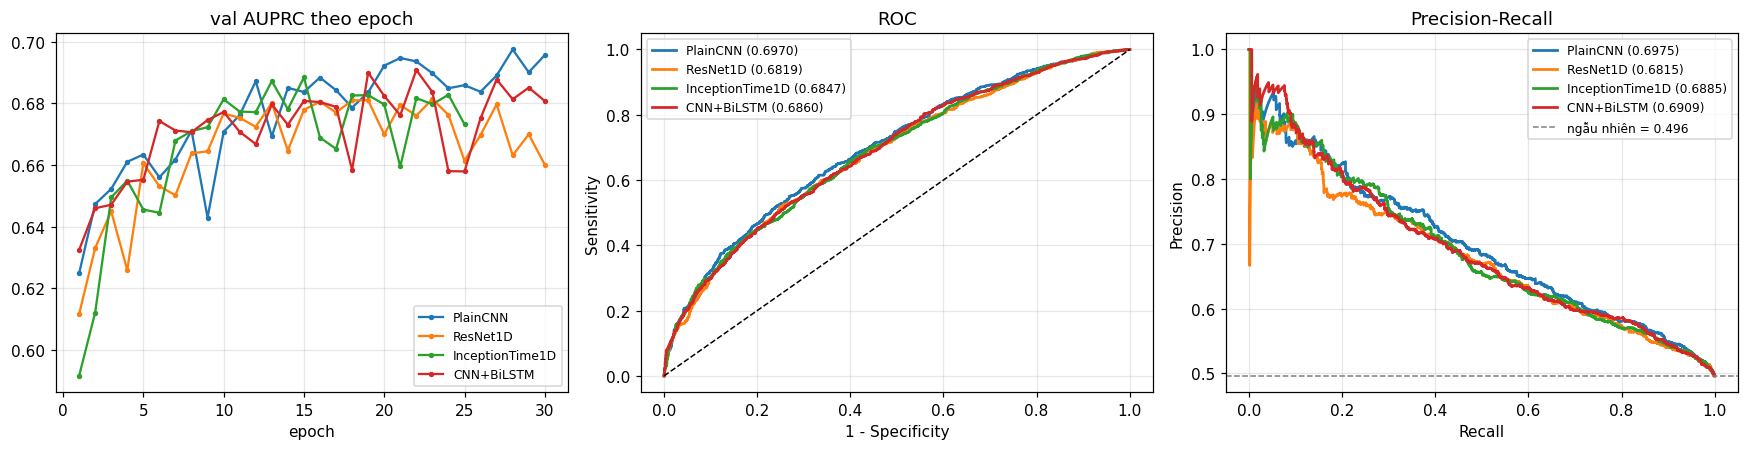

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))

for name, r in RESULTS.items():
    h = pd.DataFrame(r["hist"])
    ax[0].plot(h.epoch, h.val_auprc, marker="o", ms=2.5, label=name)
ax[0].set_title("val AUPRC theo epoch"); ax[0].set_xlabel("epoch")
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

base = float(np.mean(next(iter(RESULTS.values()))["y"]))
for name, r in RESULTS.items():
    if len(np.unique(r["y"].astype(int))) != 2:
        continue
    fpr, tpr, _ = roc_curve(r["y"], r["p"])
    ax[1].plot(fpr, tpr, lw=1.8, label=f"{name} ({r['metrics']['auroc']:.4f})")
    prec, rec, _ = precision_recall_curve(r["y"], r["p"])
    ax[2].plot(rec, prec, lw=1.8, label=f"{name} ({r['metrics']['auprc']:.4f})")

ax[1].plot([0, 1], [0, 1], "k--", lw=1)
ax[1].set_xlabel("1 - Specificity"); ax[1].set_ylabel("Sensitivity")
ax[1].set_title("ROC"); ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)

ax[2].axhline(base, ls="--", c="gray", lw=1, label=f"ngẫu nhiên = {base:.3f}")
ax[2].set_xlabel("Recall"); ax[2].set_ylabel("Precision")
ax[2].set_title("Precision-Recall"); ax[2].legend(fontsize=8); ax[2].grid(alpha=.3)

plt.tight_layout()
plt.show()

## 16b. Hiệu chuẩn xác suất (ECE) — model tốt nhất

Đầu ra của mỗi model là **xác suất liên tục**, nên độ tin cậy của con số quan trọng ngang khả năng
phân biệt. ECE đo trung bình khoảng cách giữa xác suất model nói và tỷ lệ đúng thực tế — áp dụng
cho **model tốt nhất theo AUPRC** (`BEST_MODEL`). Bổ sung từ notebook 01/02.

`pos_weight` cố tình đẩy xác suất về phía lớp dương để bù mất cân bằng, nên **ECE cao là điều đã
được dự báo trước** — muốn dùng xác suất tuyệt đối thì phải hiệu chuẩn lại (Platt/isotonic) trên
một tập riêng.

In [ ]:
def ece_table(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_prob = np.asarray(y_prob, dtype=float).ravel()
    edges = np.linspace(0, 1, n_bins + 1)
    idx = np.clip(np.digitize(y_prob, edges[1:-1]), 0, n_bins - 1)
    ece, rows = 0.0, []
    for b in range(n_bins):
        m = idx == b
        if not m.sum():
            continue
        conf, acc = float(y_prob[m].mean()), float(y_true[m].mean())
        ece += m.sum() / len(y_prob) * abs(acc - conf)
        rows.append({"bin": f"[{edges[b]:.1f},{edges[b + 1]:.1f})", "n": int(m.sum()),
                     "xác suất TB": conf, "tỷ lệ dương thật": acc, "lệch": acc - conf})
    return float(ece), pd.DataFrame(rows)


_best_y, _best_p = RESULTS[BEST_MODEL]["y"], RESULTS[BEST_MODEL]["p"]
ECE, tbl = ece_table(_best_y, _best_p)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot([0, 1], [0, 1], "k--", lw=1, label="hiệu chuẩn hoàn hảo")
ax[0].plot(tbl["xác suất TB"], tbl["tỷ lệ dương thật"], marker="o", lw=2, label=BEST_MODEL)
ax[0].set_xlabel("xác suất mô hình dự đoán"); ax[0].set_ylabel("tỷ lệ dương tính thực tế")
ax[0].set_title(f"Reliability diagram — ECE = {ECE:.4f}"); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].hist(_best_p, bins=25, color="#4C78A8")
ax[1].set_title("Phân phối xác suất trên val"); ax[1].set_xlabel("xác suất"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

print(f"{BEST_MODEL}  |  ECE = {ECE:.4f}  |  Brier = {RESULTS[BEST_MODEL]['metrics']['brier']:.4f}")
display(tbl.round(4))

## 17. Lưu ý khi kết luận

**Đừng đọc chênh lệch nhỏ như một cải thiện thật.** Seed đã cố định, nhưng `cudnn.benchmark` và AMP
khiến mỗi lần chạy lại lệch khoảng **±0,015 AUROC**. Chạy lặp lại cùng một notebook đã cho AUROC
STEMI dao động 0,9232 → 0,9362. Vì vậy hai mô hình cách nhau dưới ~0,015 AUROC nên coi là **ngang
nhau**, không phải cái này hơn cái kia.

Muốn kết luận chắc chắn thì phải chạy nhiều seed cho mỗi kiến trúc rồi so trung bình ± độ lệch
chuẩn. Notebook này chạy một seed nên chỉ đủ để **loại bỏ** những kiến trúc kém hẳn, chưa đủ để
xếp hạng những cái sát nhau.

**Chỉ có một lần chia train/val**, chưa cross-validation, nên khoảng tin cậy của các metric chưa
được ước lượng.

**Tập test ẩn 10% không được đụng tới** ở bất kỳ bước nào — cả việc chọn mô hình lẫn chọn ngưỡng đều
làm trên validation.

---

## 18. Chuyển từ chạy thử sang chạy thật

Ở **mục 2**, đổi `RUN_MODE = "debug"` thành `RUN_MODE = "full"` rồi **Run all**.

Chế độ `full` train cả 4 mô hình trên 17.960 bản ghi, tối đa 30 epoch mỗi mô hình — khoảng
**15–20 phút** trên GPU rời, **35–50 phút** trên Colab T4.

Notebook này dùng chung file cache với `02_ischemia_acs_classifier.ipynb`, nên nếu bạn đã chạy notebook kia ở chế độ
`full` trước thì bước tiền xử lý được bỏ qua hoàn toàn.

**Nếu phiên Colab đứt giữa chừng:** Run all lại. Những mô hình đã train xong được nạp từ checkpoint
và bỏ qua, chỉ train tiếp phần còn thiếu.